In [2]:
from google.colab import files

# This opens a file picker — upload your kaggle.json file
files.upload()

Saving orders_data.csv to orders_data.csv


{'orders_data.csv': b'Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent\r\n1,01-03-2023,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2\r\n2,15-08-2023,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3\r\n3,10-01-2023,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5\r\n4,18-06-2022,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2\r\n5,13-07-2022,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5\r\n6,13-03-2022,Not Available,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,FUR-FU-10001487,50,50,7,3\r\n7,28-12-2022,

In [3]:
import pandas as pd

df = pd.read_csv('orders_data.csv')
df.head()

,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,1,01-03-2023,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,15-08-2023,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,10-01-2023,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,18-06-2022,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,13-07-2022,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


In [4]:
df.shape

(9994, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order Id          9994 non-null   int64 
 1   Order Date        9994 non-null   object
 2   Ship Mode         9993 non-null   object
 3   Segment           9994 non-null   object
 4   Country           9994 non-null   object
 5   City              9994 non-null   object
 6   State             9994 non-null   object
 7   Postal Code       9994 non-null   int64 
 8   Region            9994 non-null   object
 9   Category          9994 non-null   object
 10  Sub Category      9994 non-null   object
 11  Product Id        9994 non-null   object
 12  cost price        9994 non-null   int64 
 13  List Price        9994 non-null   int64 
 14  Quantity          9994 non-null   int64 
 15  Discount Percent  9994 non-null   int64 
dtypes: int64(6), object(10)
memory usage: 1.2+ MB


In [6]:
df.isnull().sum()

,0
Order Id,0
Order Date,0
Ship Mode,1
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0


In [7]:
df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', 'Not Available', 'unknown',
       'First Class', nan, 'Same Day'], dtype=object)

In [8]:
import numpy as np
df['Ship Mode'] = df['Ship Mode'].replace({'Not Available': np.nan, 'unknown': np.nan}) #Updating unknown and Not Available as nan
df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', nan, 'First Class', 'Same Day'],
      dtype=object)

In [9]:
#Now we will fill the null_values in ship_mode by MODE, coz it's a categorical data
mode_ship = df['Ship Mode'].mode()[0]
print("Mode:", mode_ship)
df['Ship Mode'] = df['Ship Mode'].fillna(mode_ship)

print("Remaining nulls:", df['Ship Mode'].isna().sum())

Mode: Standard Class
Remaining nulls: 0


In [10]:
#Convert the 'Order Date' column to a datetime type
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Order Date'].dtype

#These date conversion is usefull for time-based analysis like monthly sales trends.

dtype('<M8[ns]')

In [11]:
df.groupby('Category')['Sub Category'].count() #THis shows How many orders of each of each categoris NOT quantity

,Sub Category
Category,
Furniture,2121
Office Supplies,6026
Technology,1847


Total orders per category not Quantity

* Furniture = 	2121
* Office Supplies= 	6026
* Technology=	1847

In [12]:
df.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent'],
      dtype='object')

In [13]:
##How much quanties of each category got sold?

total_quantity_categories = df.groupby('Category')['Quantity'].sum()
print('total_quantity_categories: ', total_quantity_categories)


total_quantity_categories:  Category
Furniture           8028
Office Supplies    22906
Technology          6939
Name: Quantity, dtype: int64


Total Quantitys of each category order

Furniture           8028

Office Supplies    22906

Technology          6939


Now, we want to know the Average selling price of each category

In [14]:
df['Selling Price'] = df['List Price'] * (1 - df['Discount Percent'] / 100) ##  calculate the **actual selling price** after discount
avg_price = df.groupby('Category')['Selling Price'].mean().reset_index()    ### step 2 — Mean selling price of each category
avg_price.columns = ['Category', 'Avg Selling Price'] ##just renaming the selling price col for this output
print(avg_price)

#This is the avg unit selling price after giving discount


          Category  Avg Selling Price
0        Furniture         337.265771
1  Office Supplies         115.108613
2       Technology         436.856253


In [15]:
df.groupby('Category')['List Price'].mean().round(2)
# This is the average selling price before discount(MRP)


,List Price
Category,
Furniture,349.55
Office Supplies,119.25
Technology,452.74


In [16]:
df.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent', 'Selling Price'],
      dtype='object')

In [17]:
#Total selling price per quantity
#Create neew col total sales --
df['Total Sales'] = df['Quantity'] * df['Selling Price']
df[['Quantity', 'Selling Price', 'Total Sales']].head()



,Quantity,Selling Price,Total Sales
0,2,254.8,509.6
1,3,708.1,2124.3
2,2,9.5,19.0
3,5,940.8,4704.0
4,2,19.0,38.0


In [18]:
df.groupby('Category')['Total Sales'].sum() #Total Sales per category

,Total Sales
Category,
Furniture,3720742.4
Office Supplies,3423675.1
Technology,3934910.7


In [19]:
# Total Profit  in COnsumer segment
#PROFIT = SELLING PRICE - COST PRICE
df['Unit Profit'] = df['Selling Price'] - df['cost price']
consumer_profit = df[df['Segment'] == 'Consumer']['Unit Profit'].sum() #filter for Consumer segment and sum the profit
print("Total Unit Profit for Consumer Segment:", consumer_profit)

Total Unit Profit for Consumer Segment: 101585.99999999999


In [20]:
#Create a pivot table showing total quantity sold by state and category.
pivot_table = df.pivot_table(
    values='Quantity',     #values inside the block of a table
    index='State',         #Row
    columns='Category',    #Cols
    aggfunc='sum',
    fill_value=0
)

pivot_table['Total'] = pivot_table.sum(axis=1)
pivot_table.loc['Grand Total'] = pivot_table.sum(axis=0)

pivot_table
#

Category,Furniture,Office Supplies,Technology,Total
State,,,,
Alabama,54,149,53,256
Arizona,188,501,173,862
Arkansas,43,135,62,240
California,1696,4566,1405,7667
Colorado,200,344,149,693
Connecticut,46,206,29,281
Delaware,64,244,59,367
District of Columbia,8,24,8,40
Florida,299,820,260,1379


/tmp/ipykernel_771/2476254979.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Category', y='Total Sales', palette='pastel') # plot


(Text(0.5, 1.0, 'Total Sales by Category'),
 Text(0.5, 0, 'Category'),
 Text(0, 0.5, 'Total Sales'))

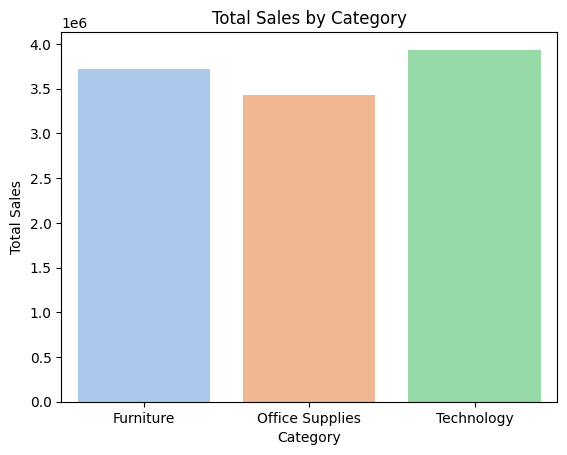

In [21]:
# Bar chart of total sales by category.

import matplotlib.pyplot as plt
import seaborn as sns

category_sales = df.groupby('Category')['Total Sales'].sum().reset_index()   # prepare data
sns.barplot(data=category_sales, x='Category', y='Total Sales', palette='pastel') # plot
plt.title('Total Sales by Category'), plt.xlabel('Category'), plt.ylabel('Total Sales')



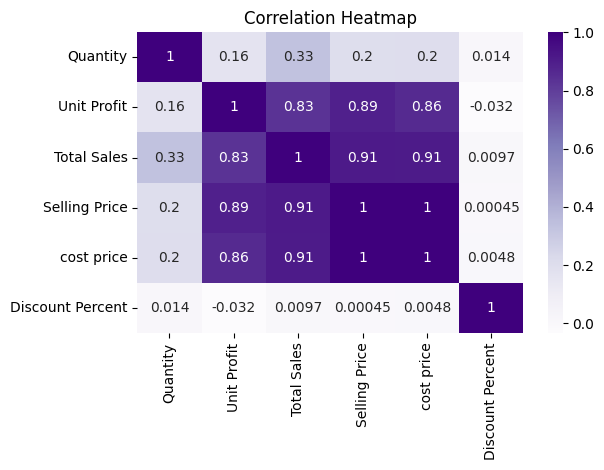

In [22]:
#correlation across all numerical columns using a heatmap:
sns.heatmap(
    df[['Quantity', 'Unit Profit', 'Total Sales', 'Selling Price', 'cost price', 'Discount Percent']].corr(),
    annot=True,       # show numbers inside boxes
    cmap='Purples',  # red = positive, blue = negative
)

plt.title('Correlation Heatmap'), plt.tight_layout()
plt.show()

In [23]:
#18. Handling Duplicates: Identify and remove any duplicate records in the dataset.
#check how many duplicates exist
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


In [24]:
# Extract data for the year 2023
data_2023 = df[df['Order Date'].dt.year == 2023]
print("Total orders in 2023:", len(data_2023))
data_2023.head()

Total orders in 2023: 4957


,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent,Selling Price,Total Sales,Unit Profit
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2,254.8,509.6,14.8
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3,708.1,2124.3,108.1
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5,9.5,19.0,-0.5
8,9,2023-03-23,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Binders,OFF-BI-10003910,20,20,3,2,19.6,58.8,-0.4
9,10,2023-05-16,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Appliances,OFF-AP-10002892,90,110,5,3,106.7,533.5,16.7


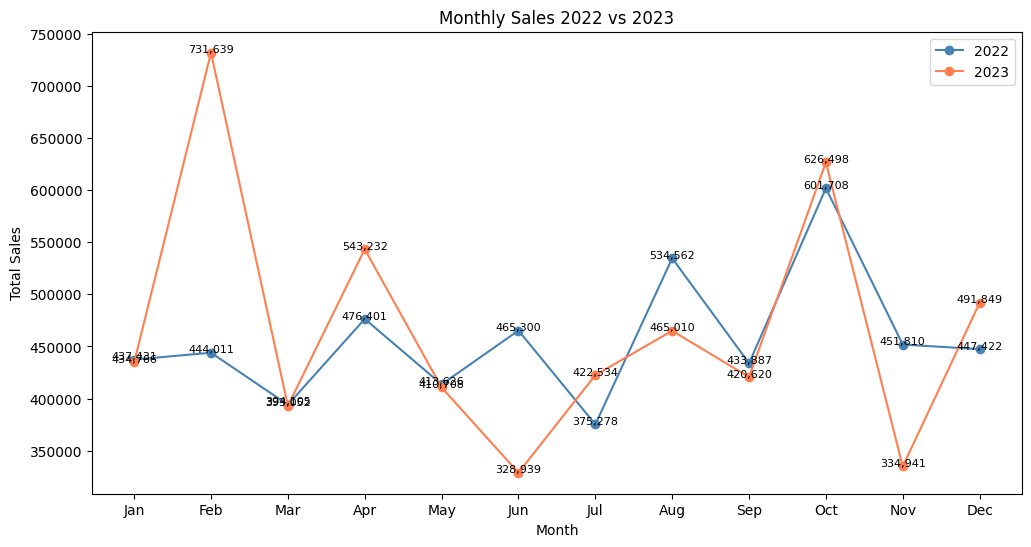

In [25]:
#Time-Series Analysis: Plot a time-series graph of monthly sales of year 2022 and 2023.

#First we will separate 2022 and 2023 year and make a new df
df_2022 = df[df['Order Date'].dt.year == 2022]
df_2023 = df[df['Order Date'].dt.year == 2023]

#Then we will groupby out month with total sales and sum it.
monthly_2022 = df_2022.groupby(df_2022['Order Date'].dt.month)['Total Sales'].sum()
monthly_2023 = df_2023.groupby(df_2023['Order Date'].dt.month)['Total Sales'].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_2022.index, monthly_2022.values, marker='o', label='2022', color='steelblue')
plt.plot(monthly_2023.index, monthly_2023.values, marker='o', label='2023', color='coral')

for x, y in zip(monthly_2022.index, monthly_2022.values):        #This is for the values near the marker
    plt.text(x, y, f'{y:,.0f}', ha='center', fontsize=8)

for x, y in zip(monthly_2023.index, monthly_2023.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', fontsize=8)

plt.title('Monthly Sales 2022 vs 2023'), plt.xlabel('Month'), plt.ylabel('Total Sales')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.show()

In [26]:
#What is the monthly growth rate in sales for furniture?
#filter furniture and get monthly sales
furniture_monthly = df[df['Category'] == 'Furniture'].groupby(df['Order Date'].dt.to_period('M'))['Total Sales'].sum().reset_index()

# step 2 — calculate monthly growth rate
furniture_monthly['Growth Rate %'] = furniture_monthly['Total Sales'].pct_change() * 100

print(furniture_monthly)

   Order Date  Total Sales  Growth Rate %
0     2022-01     170244.5            NaN
1     2022-02     192062.9      12.815921
2     2022-03     150128.1     -21.833889
3     2022-04     162806.9       8.445321
4     2022-05     110578.8     -32.079783
5     2022-06     159075.8      43.857412
6     2022-07     137750.0     -13.406062
7     2022-08     162276.8      17.805299
8     2022-09     107151.9     -33.969674
9     2022-10     229024.8     113.738440
10    2022-11     203673.6     -11.069194
11    2022-12     137431.1     -32.523852
12    2023-01     126379.8      -8.041339
13    2023-02     217851.0      72.378022
14    2023-03     128026.4     -41.232127
15    2023-04     139036.1       8.599554
16    2023-05     144279.3       3.771107
17    2023-06      96551.5     -33.080144
18    2023-07     130781.9      35.452997
19    2023-08     230523.5      76.265599
20    2023-09     157022.7     -31.884298
21    2023-10     148430.2      -5.472139
22    2023-11     120961.5     -18

In [27]:
# Convert Period to datetime
furniture_monthly['Order Date'] = furniture_monthly['Order Date'].astype(str)
furniture_monthly['Order Date'] = pd.to_datetime(furniture_monthly['Order Date'])

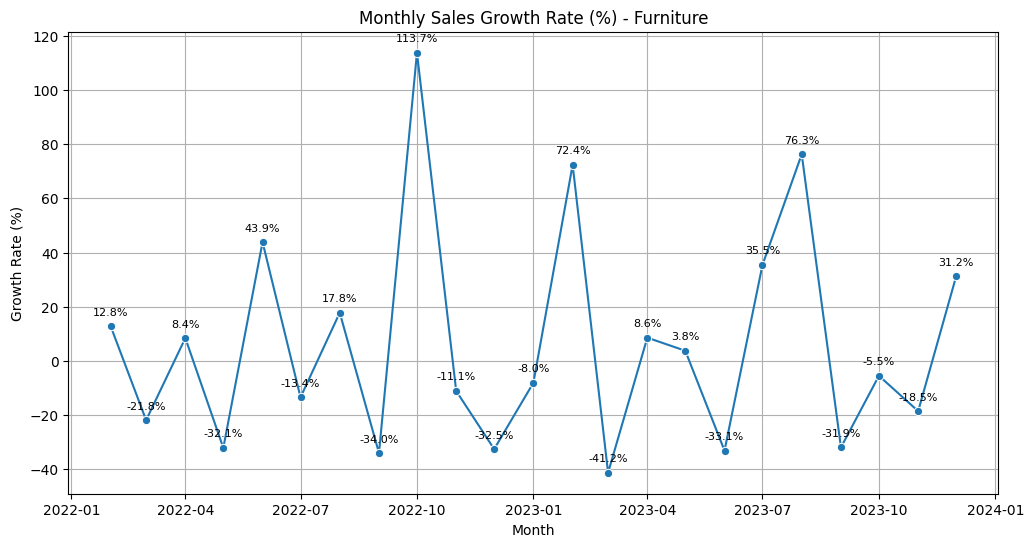

In [28]:
# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=furniture_monthly, x='Order Date',y='Growth Rate %', marker='o')

for x, y in zip(furniture_monthly['Order Date'],
                furniture_monthly['Growth Rate %']):
    plt.annotate(
        f'{y:.1f}%',
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=8
    )

plt.title('Monthly Sales Growth Rate (%) - Furniture'), plt.xlabel('Month'), plt.ylabel('Growth Rate (%)')
plt.grid(True)
plt.show()

In [29]:
# outlier detection using IQR
Q1 = df.groupby('Category')['Selling Price'].transform('quantile', 0.25)
Q3 = df.groupby('Category')['Selling Price'].transform('quantile', 0.75)
IQR = Q3 - Q1

outliers = df[(df['Selling Price'] < (Q1 - 1.5 * IQR)) |
              (df['Selling Price'] > (Q3 + 1.5 * IQR))]

print("Total outliers found:", len(outliers))
outliers[['Category', 'Product Id', 'Selling Price']]

Total outliers found: 1136


,Category,Product Id,Selling Price
10,Furniture,FUR-TA-10001539,1658.7
13,Office Supplies,OFF-BI-10003656,401.8
16,Office Supplies,OFF-ST-10004186,649.9
24,Furniture,FUR-TA-10000577,988.0
27,Furniture,FUR-BO-10004834,2987.6
...,...,...,...
9948,Office Supplies,OFF-AP-10002945,2337.7
9957,Office Supplies,OFF-PA-10004039,211.2
9968,Office Supplies,OFF-BI-10004600,717.8
9979,Office Supplies,OFF-BI-10002026,426.8


/tmp/ipykernel_771/2264877481.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Selling Price', y='Category', palette='Set2', orient='h')


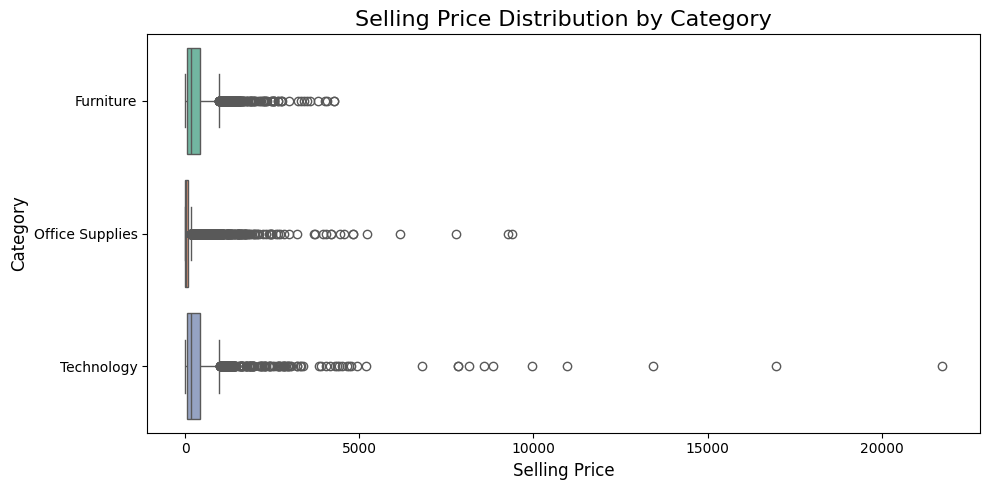

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Selling Price', y='Category', palette='Set2', orient='h')

plt.title('Selling Price Distribution by Category', fontsize=16)
plt.xlabel('Selling Price', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

In [31]:
# Build a simple linear regression model to predict 'Unit_Profit' based on 'Unit_Selling_Price' and 'Quantity'.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# step 1 — prepare data
X = df[['Selling Price', 'Quantity']]  # features
y = df['Unit Profit']                  # target

# step 2 — split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# step 3 — build and train model
model = LinearRegression()
model.fit(X_train, y_train)

# step 4 — predict
y_pred = model.predict(X_test)

# step 5 — evaluate
print("R² Score:  ", round(r2_score(y_test, y_pred), 4))
print("MSE:       ", round(mean_squared_error(y_test, y_pred), 4))
print("RMSE:      ", round(mean_squared_error(y_test, y_pred)**0.5, 4))
print("\nCoefficients:")
print(f"  Selling Price : {model.coef_[0]:.4f}")
print(f"  Quantity      : {model.coef_[1]:.4f}")
print(f"  Intercept     : {model.intercept_:.4f}")

R² Score:   0.8149
MSE:        1950.0702
RMSE:       44.1596

Coefficients:
  Selling Price : 0.0984
  Quantity      : -0.1110
  Intercept     : -1.0067


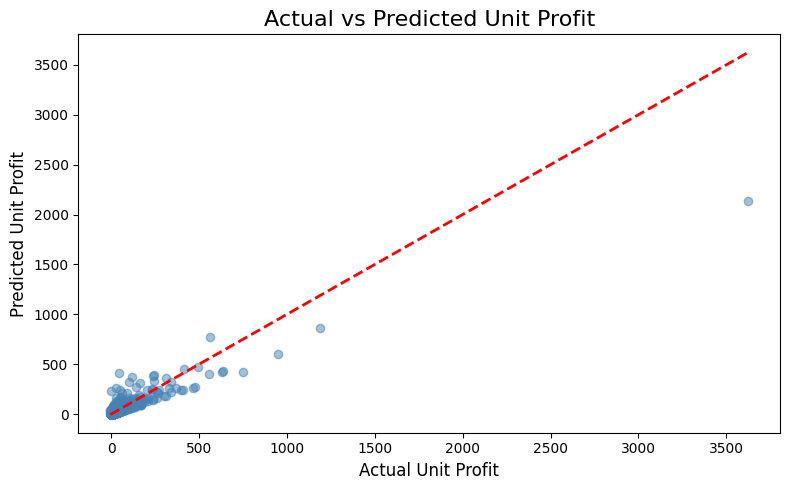

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--')  # perfect prediction line

plt.title('Actual vs Predicted Unit Profit', fontsize=16)
plt.xlabel('Actual Unit Profit', fontsize=12)
plt.ylabel('Predicted Unit Profit', fontsize=12)
plt.tight_layout()
plt.show()

In [33]:
# fix all calculated columns
df['Selling Price'] = df['List Price'] * (1 - df['Discount Percent'] / 100)
df['Total Sales'] = df['Quantity'] * df['Selling Price']
df['Unit Profit'] = df['Selling Price'] - df['cost price']

# verify
print(df[['List Price', 'Discount Percent', 'Selling Price', 'Total Sales', 'Unit Profit']].head())

   List Price  Discount Percent  Selling Price  Total Sales  Unit Profit
0         260                 2          254.8        509.6         14.8
1         730                 3          708.1       2124.3        108.1
2          10                 5            9.5         19.0         -0.5
3         960                 2          940.8       4704.0        160.8
4          20                 5           19.0         38.0         -1.0


In [34]:
df.columns

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent', 'Selling Price', 'Total Sales', 'Unit Profit'],
      dtype='object')

In [35]:
df_powerbi = df[[
    'Order Date', 'Ship Mode', 'Segment',
    'City', 'State', 'Region',
    'Category', 'Sub Category',
    'Quantity', 'Selling Price',
    'Discount Percent', 'Total Sales', 'Unit Profit'
]
]

df_powerbi.to_csv('shipment_orders_powerbi.csv', index=False)


In [36]:
df_powerbi.head()

,Order Date,Ship Mode,Segment,City,State,Region,Category,Sub Category,Quantity,Selling Price,Discount Percent,Total Sales,Unit Profit
0,2023-03-01,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Bookcases,2,254.8,2,509.6,14.8
1,2023-08-15,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Chairs,3,708.1,3,2124.3,108.1
2,2023-01-10,Second Class,Corporate,Los Angeles,California,West,Office Supplies,Labels,2,9.5,5,19.0,-0.5
3,2022-06-18,Standard Class,Consumer,Fort Lauderdale,Florida,South,Furniture,Tables,5,940.8,2,4704.0,160.8
4,2022-07-13,Standard Class,Consumer,Fort Lauderdale,Florida,South,Office Supplies,Storage,2,19.0,5,38.0,-1.0


In [37]:

from google.colab import files
# files.download('shipment_orders_powerbi.csv')